# Cityscapes Dataset Exploration

Quick notebook to inspect splits, file counts, and visualize sample images + annotations.

In [9]:
import os
import glob
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [10]:
# Adjust this path if needed
cityscapes_path = "datasets/cityscapes"
gt_dir = os.path.join(cityscapes_path, 'gtFine')
img_dir = os.path.join(cityscapes_path, 'leftImg8bit_trainvaltest')
print('gtFine exists:', os.path.isdir(gt_dir))
print('leftImg8bit_trainvaltest exists:', os.path.isdir(img_dir))

gtFine exists: True
leftImg8bit_trainvaltest exists: True


In [11]:
# List available splits and a few cities
for folder in ['train', 'val', 'test']:
    p = os.path.join(gt_dir, folder)
    if os.path.isdir(p):
        cities = sorted(os.listdir(p))
        print(f'{folder}: {len(cities)} cities, sample:', cities[:5])
    else:
        print(f'{folder}: not present')

train: 18 cities, sample: ['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt']
val: 3 cities, sample: ['frankfurt', 'lindau', 'munster']
test: 6 cities, sample: ['berlin', 'bielefeld', 'bonn', 'leverkusen', 'mainz']


In [12]:
# Count files by extension under gtFine and images
def count_files(root, pattern='**/*'):
    return sum(1 for _ in Path(root).rglob(pattern) if _.is_file())

print('gtFine total files:', count_files(gt_dir))
print('leftImg8bit_trainvaltest total files:', count_files(img_dir))

gtFine total files: 20000
leftImg8bit_trainvaltest total files: 5002


Image: datasets/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/train/stuttgart/stuttgart_000136_000019_leftImg8bit.png
GT: datasets/cityscapes/gtFine/train/stuttgart/stuttgart_000136_000019_gtFine_labelIds.png


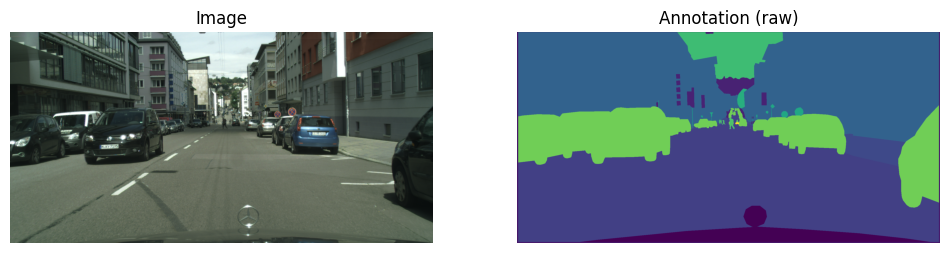

In [ ]:
# Show a sample image and its corresponding labelIds annotation
def find_corresponding_gt(image_path):
    # image_path example:
    # .../leftImg8bit_trainvaltest/leftImg8bit/train/weimar/weimar_000072_000019_leftImg8bit.png
    path = Path(image_path)
    parts = path.parts

    try:
        idx = parts.index('leftImg8bit_trainvaltest')
        rel_parts = parts[idx + 1 :]
        if rel_parts and rel_parts[0] == 'leftImg8bit':
            rel_parts = rel_parts[1:]
    except ValueError:
        try:
            idx = parts.index('leftImg8bit')
            rel_parts = parts[idx + 1 :]
        except ValueError:
            return None

    if len(rel_parts) < 3:
        return None

    split = rel_parts[0]
    city = rel_parts[1]
    image_name = rel_parts[-1]
    base_name = image_name.replace('_leftImg8bit.png', '')
    search_dir = Path(gt_dir) / split / city

    fp = search_dir / f'{base_name}_gtFine_labelIds.png'
    if fp.exists():
        return str(fp)

    for fp in search_dir.glob(base_name + '*'):
        if fp.is_file():
            return str(fp)

    return None


def show_sample(split='train'):
    img_search = Path(img_dir) / 'leftImg8bit' / split
    cities = [d for d in img_search.iterdir() if d.is_dir()]
    if not cities:
        print('No cities found in', img_search)
        return
    city = random.choice(cities)
    imgs = list(city.glob('*_leftImg8bit.png'))
    if not imgs:
        print('No images in', city)
        return
    img_path = str(random.choice(imgs))
    gt_path = find_corresponding_gt(img_path)
    print('Image:', img_path)
    print('GT:', gt_path)
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(img)
    plt.axis('off')
    if gt_path is not None:
        gt = Image.open(gt_path)
        plt.subplot(1, 2, 2)
        plt.title('Label IDs')
        plt.imshow(gt, cmap='tab20')
        plt.axis('off')
    plt.show()

# show one sample
show_sample('train')

In [ ]:
# lets infer a model here and see how it performs on a sample image, and visualize the output segmentation mask

You can re-run `show_sample()` with `split='val'` or `split='test'`.
This notebook now uses only the `gtFine_labelIds.png` annotation type for exploration.